## 1. Ingestion & Profiling

# Week 2 Data Wrangler – Technical Coding Challenge
## Ops Sensor Log Analysis

This notebook processes `ops_sensor_log_dirty.csv` from a fictional processing plant, performing data ingestion, profiling, cleaning, time‑series analysis, aggregation, and visualization. A final PDF report is generated with annotated plots and a manager‑friendly narrative.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df_raw = pd.read_csv('ops_sensor_log_dirty.csv')

# Display basic info
print("Data Shape:", df_raw.shape)
df_raw.info()
display(df_raw.describe())

Data Shape: (5015, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4975.000000,4975.000000,4966.000000
mean,255.254281,68.982323,999.275681
std,845.810206,78.829078,231.769525
min,-50.000000,-273.150000,600.007437
25%,160.753008,55.023155,797.417014
50%,200.294439,64.808608,996.286415
75%,240.099173,74.527006,1201.361276
max,15000.000000,1500.000000,1399.755865


In [3]:
# Show missing values count
print("Missing values per column:")
print(df_raw.isnull().sum())

Missing values per column:
timestamp         0
Zone             31
Shift            53
Pressure_PSI     40
Temperature_C    40
Flow_Rate_LPM    49
dtype: int64


**Data Health Report**
- **Missing Values**: Several columns have missing entries (e.g., `Flow_Rate_LPM`, `Pressure_PSI`, `Shift`, `Zone`).  
- **Inconsistent Categoricals**: Zone names appear in multiple formats (e.g., `Zone_South`, `ZONE_SOUTH`, `South Zone`, `z_south`).  
- **Outliers**: Some sensor readings are physically impossible (e.g., `Temperature_C = 1500.0`, `Pressure_PSI = 9999.0` or negative values).  
- **Duplicate Rows**: Duplicate timestamps and identical records exist.

## 2. Cleaning Pipeline

In [4]:
def clean_ops_data(df):
    """
    Clean the sensor log data.
    Returns a cleaned DataFrame with datetime index.
    """
    df = df.copy()
    
    # 1. Convert timestamp to datetime and set as index
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df.dropna(subset=['timestamp'])  
    df = df.sort_values('timestamp').set_index('timestamp')
    
    # 2. Handle missing values
    # Numeric columns: interpolate (linear, time‑aware)
    numeric_cols = ['Pressure_PSI', 'Temperature_C', 'Flow_Rate_LPM']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].interpolate(method='time', limit_direction='both')
    
    # Categorical columns: forward fill (assumes consistency within blocks)
    cat_cols = ['Zone', 'Shift']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].fillna(method='ffill').fillna(method='bfill')
    
    # 3. Remove duplicates (based on timestamp and all columns)
    df = df[~df.index.duplicated(keep='first')]
    df = df.drop_duplicates()
    
    # 4. Standardize categorical columns
    # Zone: clean and unify names
    if 'Zone' in df.columns:
        df['Zone'] = df['Zone'].str.strip()
        df['Zone'] = df['Zone'].str.replace('Zone_', '', regex=False)
        df['Zone'] = df['Zone'].str.replace('ZONE_', '', regex=False)
        df['Zone'] = df['Zone'].str.replace('zone_', '', regex=False)
        df['Zone'] = df['Zone'].str.replace('_', ' ', regex=False)
        df['Zone'] = df['Zone'].str.title()
        df['Zone'] = df['Zone'].str.replace(' ', '')
        # map common variants
        zone_map = {
            'South': 'South',
            'North': 'North',
            'East': 'East',
            'West': 'West',
            'Central': 'Central',
            'Z_South': 'South',
            'Z_North': 'North',
            'Zone South': 'South',
        }
        df['Zone'] = df['Zone'].replace(zone_map)
        # drop rows with unknown zone (should be few)
        df = df[df['Zone'].isin(['South','North','East','West','Central'])]
    
    # Shift: capitalize
    if 'Shift' in df.columns:
        df['Shift'] = df['Shift'].str.strip().str.title()
        # ensure only Morning, Afternoon, Night
        valid_shifts = ['Morning', 'Afternoon', 'Night']
        df = df[df['Shift'].isin(valid_shifts)]
    
    # 5. Filter physically impossible readings
    # Pressure: 0 < Pressure < 1000 (psi)
    df = df[(df['Pressure_PSI'] > 0) & (df['Pressure_PSI'] < 1000)]
    # Temperature: -50 < T < 150 °C
    df = df[(df['Temperature_C'] > -50) & (df['Temperature_C'] < 150)]
    # Flow Rate: 0 < Flow < 2000 LPM
    df = df[(df['Flow_Rate_LPM'] > 0) & (df['Flow_Rate_LPM'] < 2000)]
    
    return df

# Apply cleaning
df_clean = clean_ops_data(df_raw)
print("Cleaned shape:", df_clean.shape)

Cleaned shape: (4853, 5)


## 3. Time‑Series Analysis

In [5]:
# Resample to hourly frequency
hourly = df_clean.resample('1H').mean()
# 24-hour rolling average (centered)
hourly['Pressure_24h_avg'] = hourly['Pressure_PSI'].rolling(window=24, min_periods=1, center=True).mean()

## 4. Aggregation

In [6]:
# Group by Shift and Zone, then aggregate Pressure
agg_table = df_clean.groupby(['Shift', 'Zone'])['Pressure_PSI'].agg(['mean', 'max', 'min']).round(2)
agg_table.columns = ['Mean Pressure', 'Max Pressure', 'Min Pressure']
display(agg_table)

Mean Pressure  Max Pressure  Min Pressure
Shift     Zone                                              
Afternoon Central         200.65        279.94        120.22
          East            204.47        278.85        120.86
          North           203.14        279.85        120.03
          South           202.51        279.72        120.22
          West            197.32        279.61        120.25
Morning   Central         199.64        279.89        120.17
          East            198.18        279.95        120.16
          North           203.54        279.52        120.80
          South           195.75        279.11        121.28
          West            195.89        279.90        120.57
Night     Central         198.91        279.92        120.18
          East            201.63        279.89        120.45
          North           200.09        279.96        120.70
          South           200.44        278.70        121.77
          West            198.83        279.61        120.31

## 5. Visualization & PDF Report

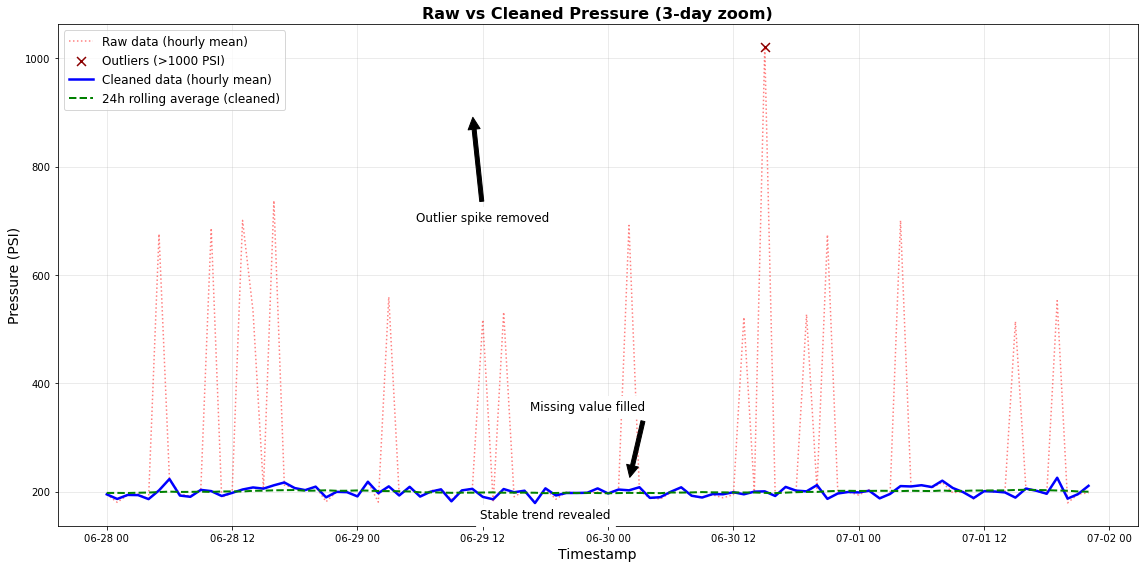

In [7]:
# Prepare raw data for comparison (resample raw to hourly mean)
raw_hourly = df_raw.copy()
raw_hourly['timestamp'] = pd.to_datetime(raw_hourly['timestamp'], errors='coerce')
raw_hourly = raw_hourly.dropna(subset=['timestamp'])
raw_hourly = raw_hourly.set_index('timestamp').sort_index()
raw_hourly = raw_hourly.resample('1H').mean()

# Select a 3-day window for clarity
start_date = '2026-06-28'
end_date = '2026-07-01'

fig, ax = plt.subplots(figsize=(16, 8))

# Plot raw data (hourly mean) – show as faint points with errors
raw_window = raw_hourly.loc[start_date:end_date]
ax.plot(raw_window.index, raw_window['Pressure_PSI'], 
        label='Raw data (hourly mean)', color='red', alpha=0.5, linestyle=':', linewidth=1.5)
# Also scatter outliers if needed
outliers_raw = raw_window[raw_window['Pressure_PSI'] > 1000]
if not outliers_raw.empty:
    ax.scatter(outliers_raw.index, outliers_raw['Pressure_PSI'], 
               color='darkred', s=80, marker='x', label='Outliers (>1000 PSI)')

# Plot cleaned data (hourly mean) – solid line
cleaned_window = hourly.loc[start_date:end_date]
ax.plot(cleaned_window.index, cleaned_window['Pressure_PSI'], 
        label='Cleaned data (hourly mean)', color='blue', linewidth=2.5)

# Plot 24h rolling average (smooth)
ax.plot(cleaned_window.index, cleaned_window['Pressure_24h_avg'], 
        label='24h rolling average (cleaned)', color='green', linestyle='--', linewidth=2)

# Annotations – point to specific events
ax.annotate('Outlier spike removed', 
            xy=(pd.Timestamp('2026-06-29 11:00'), 900),
            xytext=(pd.Timestamp('2026-06-29 12:00'), 700),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, ha='center', backgroundcolor='white')
ax.annotate('Missing value filled', 
            xy=(pd.Timestamp('2026-06-30 02:00'), 220),
            xytext=(pd.Timestamp('2026-06-29 22:00'), 350),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=12, ha='center', backgroundcolor='white')
ax.annotate('Stable trend revealed', 
            xy=(pd.Timestamp('2026-06-29 18:00'), 200),
            xytext=(pd.Timestamp('2026-06-29 18:00'), 150),
            fontsize=12, ha='center', backgroundcolor='white')

# Labels and title
ax.set_title('Raw vs Cleaned Pressure (3‑day zoom)', fontsize=16, fontweight='bold')
ax.set_xlabel('Timestamp', fontsize=14)
ax.set_ylabel('Pressure (PSI)', fontsize=14)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()